# The encoder of *Efficient VSAs from Histogram Recovery*

An implementation of the encoder from Zirui (Ken) Deng and Netanel Raviv,
*Efficient Vector Symbolic Architectures from Histogram Recovery*
(arXiv:2511.01838v2) — the local copy is `histo.pdf`.

The paper's code $\mathcal{C}$ is the concatenation of a **Reed–Solomon** outer code with a
**Hadamard** inner code, pushed into $\mathbb{C}$ by an isomorphism $\phi$. That is §III, eq. (1):

$$\mathcal{C} \;=\; \bigl\{\,\bigl(\phi(f_{\mathrm{Had}}(c_1)),\,\ldots,\,\phi(f_{\mathrm{Had}}(c_N))\bigr) \;\bigm|\; c \in \mathcal{C}_{\mathrm{RS}}\,\bigr\}$$

so the encoder is exactly the three steps below, applied left to right.

| Step | What happens | Domain → codomain | Paper |
|---|---|---|---|
| **1** | Reed–Solomon encode | $\mathbb{F}_{p^m}^{K} \to \mathbb{F}_{p^m}^{N}$, $N = p^m$ | §III |
| **2** | Hadamard encode each symbol | $\mathbb{F}_{p^m} \cong \mathbb{F}_p^m \to \mathbb{F}_p^{p^m}$ | $f_{\mathrm{Had}}$, §III |
| **3** | Apply $\phi$ pointwise | $\mathbb{F}_p \to \{\zeta^i\}_{i=0}^{p-1} \subset \mathbb{C}$ | $\phi$, §III |

A codeword therefore lives in $\mathbb{C}^{p^{2m}}$, and there are $p^{mK}$ of them.

After the three steps we check the construction against the paper's own claims
(Proposition 1's incoherence bound, and the $\mathbb{F}_p$-linearity that makes point-wise
product binding work), then implement **§IV-A**: recovering the per-coordinate histograms
from a *superposition* of codewords by lattice decoding.

Turning those histograms back into Reed–Solomon codewords is the *histogram recovery*
problem of §IV-B (Kautz–Singleton + list decoding) and is **not** implemented here.

In [1]:
import numpy as np
from itertools import product

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# ---- parameters -------------------------------------------------------
# p prime, m >= 1  ->  N = p^m is BOTH the RS length and the Hadamard length,
# because the paper fixes N = p^m (RS is evaluated at every point of F_{p^m}).
p, m, K = 3, 2, 2

N = p ** m                 # RS length  = Hadamard length  = |F_{p^m}|
q = N                      # field size, same number; kept separate for clarity
D = N - K + 1              # RS minimum distance (MDS)
LENGTH = p ** (2 * m)      # length of a codeword of C, over C
SIZE = p ** (m * K)        # number of codewords of C

print(f"p={p}  m={m}  K={K}")
print(f"F_{{p^m}} has {q} elements;  RS is [{N}, {K}] with d = {D}")
print(f"C: length {LENGTH} over the complex numbers, {SIZE} codewords")
print(f"Proposition 1 incoherence bound  mu = 1 - D/N = {1 - D / N:.6f}")

p=3  m=2  K=2
F_{p^m} has 9 elements;  RS is [9, 2] with d = 8
C: length 81 over the complex numbers, 81 codewords
Proposition 1 incoherence bound  mu = 1 - D/N = 0.111111


### Plot theme

Two figures are heatmaps of ordered integer magnitudes and one is a single-series line, so
every colour scale here is **one hue, light → dark** — no rainbow, no categorical palette.
The `THEME` knob is a deliberate choice of surface rather than an automatic flip: the dark
values are their own steps, picked to sit against the dark surface.

In [2]:
THEME = "light"          # "light" or "dark" -- each mode has its own steps

_BLUE = ["#cde2fb", "#b7d3f6", "#9ec5f4", "#86b6ef", "#6da7ec", "#5598e7", "#3987e5",
         "#2a78d6", "#256abf", "#1c5cab", "#184f95", "#104281", "#0d366b"]  # steps 100..700

if THEME == "light":
    T = dict(surface="#fcfcfb", ink="#0b0b0b", ink2="#52514e", muted="#898781",
             grid="#e1e0d9", axis="#c3c2b7", series="#2a78d6")
    SEQ = LinearSegmentedColormap.from_list("seq", _BLUE)          # 100 -> 700
    ORD = LinearSegmentedColormap.from_list("ord", _BLUE[3:])      # >= step 250, keeps 2:1
else:
    T = dict(surface="#1a1a19", ink="#ffffff", ink2="#c3c2b7", muted="#898781",
             grid="#2c2c2a", axis="#383835", series="#3987e5")
    SEQ = LinearSegmentedColormap.from_list("seq", _BLUE[::-1])    # brighter = larger
    ORD = LinearSegmentedColormap.from_list("ord", _BLUE[:11][::-1])  # <= step 600

mpl.rcParams.update({
    "figure.facecolor": T["surface"], "axes.facecolor": T["surface"],
    "savefig.facecolor": T["surface"],
    "text.color": T["ink"], "axes.labelcolor": T["ink2"],
    "xtick.color": T["muted"], "ytick.color": T["muted"],
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.titlesize": 11, "axes.labelsize": 9,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica Neue", "Helvetica", "Arial", "DejaVu Sans"],
    "figure.dpi": 120,
})

def style(ax, title=None, sub=None):
    """Recessive chrome: no box, hairline grid, muted ticks."""
    for s in ax.spines.values():
        s.set_visible(False)
    ax.tick_params(length=0)
    if title:
        ax.set_title(title, color=T["ink"], loc="left", pad=26 if sub else 8)
    if sub:                        # offset in points, so it never collides with the title
        ax.annotate(sub, xy=(0, 1), xycoords="axes fraction", xytext=(0, 7),
                    textcoords="offset points", color=T["muted"], fontsize=8,
                    va="bottom", ha="left")
    return ax

## Step 0 — the field $\mathbb{F}_{p^m}$, and its identification with $\mathbb{F}_p^m$

Everything downstream needs one thing the paper states in passing but which the whole
construction rests on: each Reed–Solomon symbol is an element of $\mathbb{F}_{p^m}$, and to feed it
to $f_{\mathrm{Had}}$ it must be **"represented as a vector in $\mathbb{F}_p^m$."**

So we build $\mathbb{F}_{p^m}$ explicitly as $\mathbb{F}_p[x]/(f)$ for a monic irreducible $f$ of degree $m$, and
identify a field element with its **coefficient vector** in the polynomial basis
$\{1, x, \ldots, x^{m-1}\}$. That map is an isomorphism of *additive* groups
$(\mathbb{F}_{p^m}, +) \cong (\mathbb{F}_p^m, +)$, which is all $f_{\mathrm{Had}}$ and $\phi$ care about.

Elements are stored as plain integers $0, \ldots, p^m - 1$, an integer's base-$p$ digits
*being* its coefficient vector. Addition and multiplication are precomputed $q \times q$
lookup tables, which keeps the Reed–Solomon step readable at these sizes.

In [3]:
def poly_trim(a):
    a = list(a)
    while len(a) > 1 and a[-1] == 0:
        a.pop()
    return a

def poly_mul(a, b, p):
    out = [0] * (len(a) + len(b) - 1)
    for i, ai in enumerate(a):
        if ai:
            for j, bj in enumerate(b):
                out[i + j] = (out[i + j] + ai * bj) % p
    return poly_trim(out)

def poly_divmod(a, b, p):
    """Quotient and remainder of a / b over F_p (coefficients low -> high)."""
    a, b = poly_trim(a), poly_trim(b)
    db = len(b) - 1
    inv = pow(b[-1], -1, p)
    if db == 0:                                  # b is a nonzero constant
        return poly_trim([x * inv % p for x in a]), [0]
    if len(a) - 1 < db:
        return [0], a
    quo, rem = [0] * (len(a) - db), list(a)
    for i in range(len(a) - 1, db - 1, -1):
        c = rem[i] * inv % p
        if c:
            quo[i - db] = c
            for j in range(db + 1):
                rem[i - db + j] = (rem[i - db + j] - c * b[j]) % p
    return poly_trim(quo), poly_trim(rem[:db])

def monic_polys(p, d):
    """All monic degree-d polynomials over F_p."""
    for tail in product(range(p), repeat=d):
        yield list(tail) + [1]

def is_irreducible(f, p):
    """Monic f is irreducible over F_p iff it has no monic factor of degree <= deg(f)/2."""
    deg = len(f) - 1
    if deg <= 1:
        return True
    return not any(poly_divmod(f, g, p)[1] == [0]
                   for d in range(1, deg // 2 + 1) for g in monic_polys(p, d))

def find_irreducible(p, m):
    for f in monic_polys(p, m):
        if is_irreducible(f, p):
            return f
    raise RuntimeError(f"no irreducible polynomial of degree {m} over F_{p}")

In [4]:
class GF:
    """F_{p^m} as F_p[x]/(f). Element <-> int <-> base-p coefficient vector."""

    def __init__(self, p, m):
        self.p, self.m, self.q = p, m, p ** m
        self.modulus = find_irreducible(p, m)
        self._pw = p ** np.arange(m)
        # vec[a] is the F_p^m coordinate vector of the field element a -- the paper's
        # "representing each F_{p^m} entry as a vector in F_p^m".
        self.vec = np.array([[(a // p ** k) % p for k in range(m)] for a in range(self.q)],
                            dtype=np.int64)
        self.one = self.from_vec([1] + [0] * (m - 1))

        self.ADD = np.zeros((self.q, self.q), dtype=np.int64)
        self.MUL = np.zeros((self.q, self.q), dtype=np.int64)
        for a in range(self.q):
            for b in range(self.q):
                self.ADD[a, b] = self.from_vec((self.vec[a] + self.vec[b]) % p)
                prod = poly_divmod(poly_mul(list(self.vec[a]), list(self.vec[b]), p),
                                   self.modulus, p)[1]
                self.MUL[a, b] = self.from_vec((prod + [0] * m)[:m])

        self.NEG = np.array([self.from_vec((-self.vec[a]) % p) for a in range(self.q)])
        self.INV = np.zeros(self.q, dtype=np.int64)      # INV[0] is unused
        for a in range(1, self.q):
            self.INV[a] = int(np.flatnonzero(self.MUL[a] == self.one)[0])

    def from_vec(self, v):
        return int(np.asarray(v, dtype=np.int64) @ self._pw)

    def sub(self, a, b):
        return self.ADD[a, self.NEG[b]]


F = GF(p, m)
print(f"modulus f(x) = {F.modulus}  (coefficients low -> high), irreducible over F_{p}")
print(f"field element 5 <-> coefficient vector {F.vec[5 % F.q]}")

# --- the field really is a field -------------------------------------------
assert is_irreducible(F.modulus, p)
assert (F.ADD[0] == np.arange(q)).all(), "0 is not the additive identity"
assert (F.MUL[F.one] == np.arange(q)).all(), "1 is not the multiplicative identity"
assert (F.ADD == F.ADD.T).all() and (F.MUL == F.MUL.T).all(), "not commutative"
for a in range(1, q):
    assert sorted(F.MUL[a].tolist()) == list(range(q)), f"{a} has no inverse"
    assert F.MUL[a, F.INV[a]] == F.one
_rng = np.random.default_rng(0)
for _ in range(300):                                   # distributivity
    a, b, c = (int(x) for x in _rng.integers(0, q, 3))
    assert F.MUL[a, F.ADD[b, c]] == F.ADD[F.MUL[a, b], F.MUL[a, c]]
print(f"F_{{{p}^{m}}} verified: commutative, unital, every nonzero element invertible")

modulus f(x) = [1, 0, 1]  (coefficients low -> high), irreducible over F_3
field element 5 <-> coefficient vector [2 1]
F_{3^2} verified: commutative, unital, every nonzero element invertible


## Step 1 — Reed–Solomon

The outer code, $\mathcal{C}_{\mathrm{RS}}$, is an $[N, K]_{p^m}$ Reed–Solomon code with
$N = p^m$ fixed by the paper. Since $N$ equals the field size, the evaluation points are
**all** of $\mathbb{F}_{p^m}$ (including $0$):

$$\mathcal{C}_{\mathrm{RS}} \;=\; \bigl\{\,(f(\beta_1), \ldots, f(\beta_N)) \;\bigm|\; \deg f < K \,\bigr\},
\qquad \{\beta_j\} = \mathbb{F}_{p^m}.$$

A message $u \in \mathbb{F}_{p^m}^K$ is read as the coefficient vector of $f$, so encoding is
multiplication by the Vandermonde generator $G_{ij} = \beta_j^{\,i}$.

The code is **MDS**: a nonzero $f$ of degree $< K$ has at most $K-1$ roots, so every nonzero
codeword has weight at least $N - K + 1 = D$. Two consequences are load-bearing later —
$D$ is what Proposition 1's incoherence bound is stated in terms of, and the dual reading of
the same fact (*any two distinct codewords agree in at most $K-1$ positions*) is what
Lemma 2 uses.

In [5]:
betas = np.arange(N, dtype=np.int64)          # every element of F_{p^m}, as its index

# Vandermonde generator: G[i, j] = beta_j^i, built by iterated multiplication so that
# the i = 0 row is all ones (beta^0 = 1, including for beta = 0).
G = np.zeros((K, N), dtype=np.int64)
G[0] = F.one
for i in range(1, K):
    G[i] = F.MUL[G[i - 1], betas]

def rs_encode(u):
    """Message u in F_{p^m}^K  ->  Reed-Solomon codeword in F_{p^m}^N."""
    c = np.zeros(N, dtype=np.int64)
    for i in range(K):
        c = F.ADD[c, F.MUL[int(u[i]), G[i]]]
    return c

demo_u = [1, 2][:K] + [0] * max(0, K - 2)
print(f"message {demo_u}  ->  RS codeword {rs_encode(demo_u)}")

# --- MDS: min weight over nonzero codewords == D  (linear code => min weight = min dist)
messages = list(product(range(q), repeat=K))
if len(messages) <= 20000:
    weights = [int(np.count_nonzero(rs_encode(u))) for u in messages if any(u)]
    assert min(weights) == D, f"min weight {min(weights)} != N-K+1 = {D}"
    print(f"min distance = {min(weights)} = N-K+1 = {D}  -> MDS, so any two distinct "
          f"codewords agree in at most K-1 = {K - 1} positions")
else:
    print(f"min-distance check skipped: {len(messages)} codewords is too many to enumerate")

message [1, 2]  ->  RS codeword [1 0 2 7 6 8 4 3 5]
min distance = 8 = N-K+1 = 8  -> MDS, so any two distinct codewords agree in at most K-1 = 1 positions


## Step 2 — the Hadamard code matrix

The inner code takes a *single* Reed–Solomon symbol, viewed through Step 0 as a vector
$a \in \mathbb{F}_p^m$, to a length-$p^m$ vector over $\mathbb{F}_p$:

$$f_{\mathrm{Had}}(a) \;=\; \bigl(a b^{\intercal}\bigr)_{b \in \mathbb{F}_p^m}
\;=\; \text{the } a\text{'th column of a } p^m \times p^m \text{ Hadamard matrix } H.$$

The paper gives those two descriptions as equivalent, and one object delivers both. Let
$B \in \mathbb{F}_p^{p^m \times m}$ have the coordinate vector of element $j$ as its $j$'th row. Then

$$L \;=\; B B^{\intercal} \bmod p, \qquad L_{b,a} = \langle \mathrm{vec}(a), \mathrm{vec}(b)\rangle,$$

so **column $a$ of $L$ is $f_{\mathrm{Had}}(\mathrm{vec}(a))$**. $L$ holds the exponents; $\phi$ in Step 3
turns them into the entries of $H$.

$f_{\mathrm{Had}}$ is $\mathbb{F}_p$-linear in $a$ and its $p^m$ columns are distinct — checked below,
because both are needed: linearity gives the binding property in Step 4, distinctness makes
the correspondence between Hadamard codewords and field elements one-to-one, which is what
§IV-B's histograms are *about*.

In [6]:
B = F.vec                                  # row j = coordinate vector of element j
L = (B @ B.T) % p                          # L[b, a] = <vec(a), vec(b)>

def f_had(a):
    """Hadamard-encode one F_{p^m} symbol: element index a -> F_p^{p^m}."""
    return (B @ F.vec[a]) % p

assert L.shape == (N, N)
assert (L == L.T).all(), "L should be symmetric"
assert all((L[:, a] == f_had(a)).all() for a in range(N)), "column a != f_had(a)"

# F_p-linearity of f_Had. Note F_{p^m} addition IS coordinate-wise F_p^m addition,
# so F.ADD is the right notion of "a + b" on the input side.
for _ in range(200):
    a, b = (int(x) for x in _rng.integers(0, q, 2))
    assert (f_had(F.ADD[a, b]) == (f_had(a) + f_had(b)) % p).all(), "f_had is not linear"

assert len({tuple(L[:, a]) for a in range(N)}) == N, "Hadamard columns are not distinct"
print(f"L is {N}x{N} over F_{p};  f_had linear; all {N} columns distinct")
print(f"f_had(element 1) = {f_had(1)}")

L is 9x9 over F_3;  f_had linear; all 9 columns distinct
f_had(element 1) = [0 1 2 0 1 2 0 1 2]


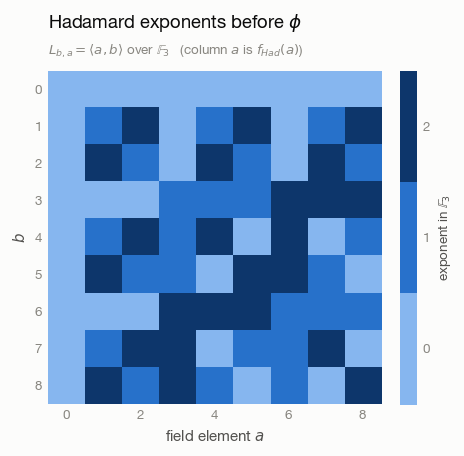

row 0 is all zeros (element 0 has zero inner product with everything): True
distinct exponent values present: [0, 1, 2]


In [7]:
fig, ax = plt.subplots(figsize=(4.6, 3.9))
im = ax.imshow(L, cmap=ORD.resampled(p), vmin=-0.5, vmax=p - 0.5, interpolation="nearest")
style(ax, "Hadamard exponents before $\\phi$",
      f"$L_{{b,a}} = \\langle a, b \\rangle$ over $\\mathbb{{F}}_{{{p}}}$   "
      f"(column $a$ is $f_{{Had}}(a)$)")
ax.set_xlabel("field element $a$")
ax.set_ylabel("$b$")
cb = fig.colorbar(im, ax=ax, ticks=range(p), fraction=0.046, pad=0.04)
cb.outline.set_visible(False)
cb.ax.tick_params(length=0)
cb.set_label(f"exponent in $\\mathbb{{F}}_{{{p}}}$", color=T["ink2"], fontsize=8)
fig.tight_layout()
plt.show()

# table view: the same information, not color-alone
print("row 0 is all zeros (element 0 has zero inner product with everything):",
      bool((L[0] == 0).all()))
print("distinct exponent values present:", sorted(set(L.ravel().tolist())))

## Step 3 — apply $\phi$, and assemble the encoder

$\phi$ is the isomorphism from the *additive* group $(\mathbb{F}_p, +)$ to the *multiplicative*
group $(\{\zeta^i\}_{i=0}^{p-1}, \cdot)$, where $\zeta \in \mathbb{C}$ is a primitive $p$'th root of
unity:

$$\phi(a) \;=\; \zeta^{a}, \qquad \zeta = e^{2\pi i / p}.$$

This single choice is what makes the whole architecture work: it sends **addition to
multiplication**, so the VSA's point-wise-product binding of §II becomes addition in the
code, and every codeword entry is a root of unity, so all codewords have the same norm.

Applying $\phi$ to the exponent matrix $L$ gives the complex Hadamard matrix $H = \zeta^{L}$,
which satisfies $H H^{\dagger} = p^m I$ — the identity used both in Proposition 1's proof and
in the lattice decoding of §IV-A.

Composing the three steps gives eq. (1). Because column $c_j$ of $H$ *is*
$\phi(f_{\mathrm{Had}}(c_j))$, the encoder reduces to **selecting the columns of $H$ indexed by
the Reed–Solomon codeword** and concatenating them. Both routes are implemented and
asserted equal, since that equivalence is the clearest way to see what eq. (1) says.

In [8]:
zeta = np.exp(2j * np.pi / p)
ZETA_POW = np.exp(2j * np.pi * np.arange(p) / p)      # [zeta^0, ..., zeta^(p-1)]

def phi(a):
    """The paper's phi, applied point-wise to exponents in F_p."""
    return ZETA_POW[np.asarray(a) % p]

# phi is a group isomorphism (F_p, +) -> ({zeta^i}, .)
assert abs(zeta ** p - 1) < 1e-12, "zeta is not a p'th root of unity"
assert all(abs(zeta ** k - 1) > 1e-9 for k in range(1, p)), "zeta is not primitive"
for a in range(p):
    for b in range(p):
        assert abs(phi((a + b) % p) - phi(a) * phi(b)) < 1e-12, "phi is not a homomorphism"
assert len({np.round(phi(a), 12).item() for a in range(p)}) == p, "phi is not injective"

H = phi(L)                                            # the complex Hadamard matrix
assert np.allclose(H @ H.conj().T, N * np.eye(N)), "H H^dagger != p^m I"
print(f"phi: 1 -> {phi(1):+.4f},  H is {H.shape[0]}x{H.shape[1]},  "
      f"H H^dag = {N} I  (Prop. 1 / IV-A)")

phi: 1 -> -0.5000+0.8660j,  H is 9x9,  H H^dag = 9 I  (Prop. 1 / IV-A)


In [9]:
def encode(u):
    """The paper's eq. (1): message in F_{p^m}^K  ->  codeword in C^{p^2m}."""
    c = rs_encode(u)
    return H[:, c].T.reshape(-1)          # concatenate phi(f_Had(c_j)) over j

def encode_explicit(u):
    """Same thing spelled out step by step, to show the three stages."""
    c = rs_encode(u)                                       # Step 1: Reed-Solomon
    blocks = [phi(f_had(int(cj))) for cj in c]             # Steps 2 and 3, per symbol
    return np.concatenate(blocks)

_u = [int(x) for x in _rng.integers(0, q, K)]
assert np.allclose(encode(_u), encode_explicit(_u)), "column selection != explicit pipeline"

cw = encode(_u)
print(f"message         {_u}")
print(f"RS codeword     {rs_encode(_u)}")
print(f"C codeword      length {cw.size} = p^2m = {LENGTH},  first block "
      f"{np.round(cw[:min(4, N)], 3)} ...")
print("eq.(1) as H-column selection == explicit f_Had then phi:  OK")

message         [8, 4]
RS codeword     [8 0 4 1 5 6 3 7 2]
C codeword      length 81 = p^2m = 81,  first block [ 1. +0.j    -0.5-0.866j -0.5+0.866j -0.5-0.866j] ...
eq.(1) as H-column selection == explicit f_Had then phi:  OK


## Step 4 — checking the construction against the paper

Three claims, each asserted rather than asserted-in-prose.

**Length and norm.** A codeword has length $p^{2m}$ and, since $\phi$ makes every entry a
root of unity, $\lVert c \rVert_2 = \sqrt{p^{2m}} = p^m$ for *every* $c$ — the first
observation in Proposition 1's proof.

**Proposition 1: $\mathcal{C}$ is $1 - \frac{N-K+1}{N}$ incoherent.** The proof combines
$HH^{\dagger} = p^m I$ (distinct Hadamard blocks are orthogonal, identical ones contribute
$N$) with the MDS agreement bound, giving
$\frac{1}{p^{2m}}\lvert c_1 c_2^{\dagger}\rvert \le 1 - D/N$. Since RS is MDS *some* pair of
codewords attains $K-1$ agreements, so the empirical maximum should not merely respect the
bound but **equal** it, at $(K-1)/N$. That is the sharper statement, so that is what gets
asserted.

**Binding.** $\mathcal{C}$ is $\mathbb{F}_p$-linear, and because $\phi$ carries addition to
multiplication this appears as

$$\mathrm{enc}(u \oplus v) \;=\; \mathrm{enc}(u) \odot \mathrm{enc}(v)$$

with $\oplus$ addition in $\mathbb{F}_{p^m}$ and $\odot$ the point-wise product. The right-hand side is
the VSA binding operation of §II; the left is a message-space addition. This is what the
paper relies on for binding-recovery via Gaussian elimination.

In [10]:
# --- length and norm, for every codeword when that is feasible -------------
sample = messages if len(messages) <= 2000 else \
    [messages[i] for i in _rng.choice(len(messages), 2000, replace=False)]

for u in sample:
    c = encode(u)
    assert c.shape == (LENGTH,)
    assert abs(np.linalg.norm(c) - np.sqrt(LENGTH)) < 1e-9
    assert np.allclose(np.abs(c), 1.0), "entries are not all roots of unity"
print(f"all {len(sample)} codewords: length {LENGTH} = p^2m, "
      f"norm {np.sqrt(LENGTH):.4f} = p^m = {p ** m}")

# --- binding: enc(u + v) == enc(u) * enc(v) --------------------------------
for _ in range(50):
    a = [int(x) for x in _rng.integers(0, q, K)]
    b = [int(x) for x in _rng.integers(0, q, K)]
    s = [int(F.ADD[a[i], b[i]]) for i in range(K)]
    assert np.allclose(encode(s), encode(a) * encode(b)), "binding property failed"
print("binding  enc(u + v) == enc(u) * enc(v)  holds  (F_p-linearity of C)")

all 81 codewords: length 81 = p^2m, norm 9.0000 = p^m = 9
binding  enc(u + v) == enc(u) * enc(v)  holds  (F_p-linearity of C)


In [11]:
# --- Proposition 1 --------------------------------------------------------
mu_bound = 1 - D / N

if len(messages) <= 1200:
    C_all = np.array([encode(u) for u in messages])
    label = f"all {len(messages)}"
else:
    idx = _rng.choice(len(messages), 1000, replace=False)
    C_all = np.array([encode(messages[i]) for i in idx])
    label = f"{len(idx)} sampled"

Gram = np.abs(C_all @ C_all.conj().T) / LENGTH
off_diag = Gram - np.diag(np.diag(Gram))
emp = off_diag.max()

assert np.allclose(np.diag(Gram), 1.0), "diagonal should be 1"
assert emp <= mu_bound + 1e-9, "Proposition 1 violated"
print(f"coherence over {label} codewords")
print(f"  empirical max |c1 c2*| / p^2m : {emp:.6f}")
print(f"  Proposition 1 bound 1 - D/N   : {mu_bound:.6f}")
print(f"  (K-1)/N                       : {(K - 1) / N:.6f}")
if len(messages) <= 1200:
    assert abs(emp - (K - 1) / N) < 1e-9, "bound should be attained"
    print("  bound is ATTAINED, so Proposition 1 is tight for these parameters")

coherence over all 81 codewords
  empirical max |c1 c2*| / p^2m : 0.111111
  Proposition 1 bound 1 - D/N   : 0.111111
  (K-1)/N                       : 0.111111
  bound is ATTAINED, so Proposition 1 is tight for these parameters


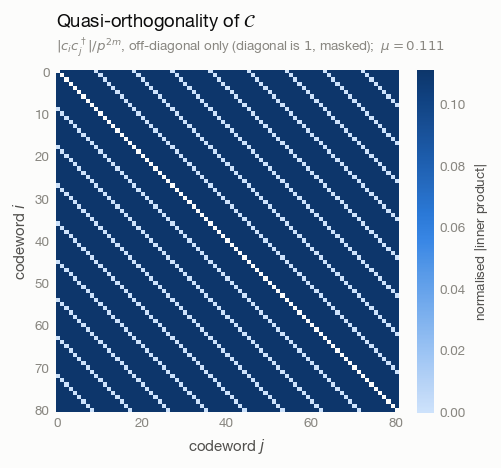

  off-diagonal value      pairs
            0.000000        324
            0.111111       2916
            bound mu   0.111111


In [12]:
fig, ax = plt.subplots(figsize=(4.8, 4.0))

# The diagonal is 1 by construction, so plotting it on a 0..1 scale flattens everything
# that actually varies. Mask it and scale to mu, which separates the two populations
# the MDS property predicts: exactly 0, or exactly mu.
Gvis = Gram.copy()
np.fill_diagonal(Gvis, np.nan)
cmap = SEQ.copy()
cmap.set_bad(T["surface"])

im = ax.imshow(Gvis, cmap=cmap, vmin=0, vmax=mu_bound, interpolation="nearest")
style(ax, "Quasi-orthogonality of $\\mathcal{C}$",
      f"$|c_i c_j^\\dagger| / p^{{2m}}$, off-diagonal only "
      f"(diagonal is $1$, masked);  $\\mu = {mu_bound:.3f}$")
ax.set_xlabel("codeword $j$")
ax.set_ylabel("codeword $i$")
cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.outline.set_visible(False)
cb.ax.tick_params(length=0)
cb.set_label("normalised $|$inner product$|$", color=T["ink2"], fontsize=8)
fig.tight_layout()
plt.show()

# table view of the same figure
vals, counts = np.unique(np.round(off_diag[np.triu_indices_from(off_diag, k=1)], 9),
                         return_counts=True)
print(f"{'off-diagonal value':>20}   {'pairs':>8}")
for v, n in zip(vals, counts):
    print(f"{v:>20.6f}   {n:>8}")
print(f"{'bound mu':>20}   {mu_bound:>8.6f}")

### What binding buys you: attributes as trivially intersecting subcodes

§II asks for $\mathcal{C} = \mathcal{C}_1 \times \cdots \times \mathcal{C}_a$ with
$\mathcal{C}_i \cap \mathcal{C}_j = \{\mathbf{0}\}$, the codewords of $\mathcal{C}_i$ serving as the
atomic vectors for attribute $i$. Splitting the $K$ message coordinates across attributes
does exactly that. With $K = 2$ we get two attributes — say colour and shape — and
`green ⊗ circle` is a point-wise product of complex vectors, while unbinding is linear
algebra over $\mathbb{F}_{p^m}$.

In [13]:
def gf_solve(A, b):
    """Solve A x = b over F_{p^m} by Gauss-Jordan on lookup tables."""
    n = len(b)
    M = np.concatenate([np.array(A, dtype=np.int64), np.array(b, dtype=np.int64).reshape(n, 1)],
                       axis=1)
    for col in range(n):
        piv = next(r for r in range(col, n) if M[r, col] != 0)
        M[[col, piv]] = M[[piv, col]]
        M[col] = F.MUL[F.INV[M[col, col]], M[col]]
        for r in range(n):
            if r != col and M[r, col] != 0:
                M[r] = F.ADD[M[r], F.NEG[F.MUL[M[r, col], M[col]]]]
    return M[:, -1]

V = G[:, :K].T                              # V[j, i] = beta_j^i, invertible (Vandermonde)

def unbind(c):
    """Codeword of C  ->  message, by reading off symbols then solving for u."""
    blocks = c.reshape(N, N)
    # t = 1, so each block's histogram is a single 1: the RS symbol at that coordinate
    hist = np.round((H.conj().T @ blocks.T).real / N).astype(int).T
    rs = np.array([int(np.argmax(h)) for h in hist])
    return [int(x) for x in gf_solve(V, rs[:K])], rs

# two attributes, one message coordinate each -> trivially intersecting subcodes
green = encode([2] + [0] * (K - 1))          # in C_colour
circle = encode([0, 3] + [0] * (K - 2))      # in C_shape

assert np.allclose(encode([0] * K), 1.0), "the identity of C should be the all-ones vector"
inter_u, _ = unbind(green * np.conj(circle) * circle)   # sanity: unbind is an inverse
assert inter_u == [2] + [0] * (K - 1)

bound = green * circle                       # binding == point-wise product
msg, rs = unbind(bound)
print(f"green            -> message {unbind(green)[0]}")
print(f"circle           -> message {unbind(circle)[0]}")
print(f"green (*) circle -> message {msg}   (recovered colour {msg[0]}, shape {msg[1]})")
assert msg == [2, 3] + [0] * (K - 2), "unbinding did not recover both attributes"
print("binding-recovery: both attributes read back from the bound vector  OK")

green            -> message [2, 0]
circle           -> message [0, 3]
green (*) circle -> message [2, 3]   (recovered colour 2, shape 3)
binding-recovery: both attributes read back from the bound vector  OK


## Step 5 — recovering Hadamard codewords by lattice decoding (§IV-A)

Superposition-recovery starts from $s = \sum_{i=1}^{t} c_i + e$, a sum of
not-necessarily-distinct codewords of $\mathcal{C}$ plus noise. Split $s$ into $N$ consecutive
blocks $s_i \in \mathbb{C}^N$. By eq. (1), block $i$ of each summand is a *column* of $H$, so

$$s_i^{\intercal} \;=\; H h_i^{\intercal} + e_i^{\intercal},
\qquad h_i \in \mathbb{Z}_{\geq 0}^{N},$$

where $h_i$ is the **histogram** of $\mathbb{F}_{p^m}$ symbols appearing at coordinate $i$ across
the $t$ superposed Reed–Solomon codewords. Recovering $h_i$ is decoding in the lattice
$H\mathbb{Z}^N$, and Corollary 1 says plain rounding does it:

$$h_i \;=\; \mathrm{round}\!\left(\tfrac{1}{N}\,\Re\bigl(H^{\dagger} s_i^{\intercal}\bigr)\right).$$

Corollary 2 gives the sufficient noise condition $\lVert e_i \rVert_2 < \sqrt{N}/2$.

This is where the paper's title problem begins: these histograms are the *input* to
histogram recovery (§IV-B), which finds the Reed–Solomon codewords obeying them. That part
is not implemented here.

In [14]:
Hdag = H.conj().T

def decode_histograms(s):
    """Corollary 1: superposition in C^{p^2m}  ->  N histograms over F_{p^m}."""
    blocks = s.reshape(N, N)
    return np.round((Hdag @ blocks.T).real / N).astype(int).T

def true_histograms(rs_codewords):
    return np.array([np.bincount([int(c[i]) for c in rs_codewords], minlength=q)
                     for i in range(N)])

t = 3
msgs_t = [[int(x) for x in _rng.integers(0, q, K)] for _ in range(t)]
rs_t = [rs_encode(u) for u in msgs_t]
s = sum(encode(u) for u in msgs_t)                 # noiseless superposition

Htrue = true_histograms(rs_t)
Hgot = decode_histograms(s)
assert (Hgot == Htrue).all(), "noiseless histogram recovery failed"
assert (Htrue.sum(axis=1) == t).all(), "every histogram should sum to t"
print(f"t = {t} superposed codewords, messages {msgs_t}")
print(f"RS symbols at coordinate 0: {[int(c[0]) for c in rs_t]}")
print(f"recovered histogram h_0   : {Hgot[0].tolist()}")
print(f"all {N} histograms recovered exactly from the noiseless superposition  OK")

t = 3 superposed codewords, messages [[2, 6], [2, 6], [8, 7]]
RS symbols at coordinate 0: [2, 2, 8]
recovered histogram h_0   : [0, 0, 2, 0, 0, 0, 0, 0, 1]
all 9 histograms recovered exactly from the noiseless superposition  OK


In [15]:
# --- Corollary 2: sweep ||e_i||_2 across the sqrt(N)/2 threshold ------------
threshold = np.sqrt(N) / 2
rhos = np.array([0.25, 0.5, 0.75, 0.9, 1.0, 1.25, 1.5, 1.75, 2.0, 2.5, 3.0])
TRIALS = 120
rate = np.zeros_like(rhos)

for k, rho in enumerate(rhos):
    ok = 0
    for _ in range(TRIALS):
        e = (_rng.normal(size=(N, N)) + 1j * _rng.normal(size=(N, N)))
        e *= (rho * threshold) / np.linalg.norm(e, axis=1, keepdims=True)   # per-block norm
        ok += int((decode_histograms(s + e.reshape(-1)) == Htrue).all())
    rate[k] = ok / TRIALS

guaranteed = rhos < 1.0
assert (rate[guaranteed] == 1.0).all(), "Corollary 2's guarantee was violated"
print(f"Corollary 2 threshold  sqrt(N)/2 = {threshold:.4f}")
print(f"{'||e_i|| / threshold':>20}   {'success rate':>12}")
for r_, v in zip(rhos, rate):
    print(f"{r_:>20.2f}   {v:>12.3f}")

Corollary 2 threshold  sqrt(N)/2 = 1.5000
 ||e_i|| / threshold   success rate
                0.25          1.000
                0.50          1.000
                0.75          1.000
                0.90          1.000
                1.00          1.000
                1.25          1.000
                1.50          0.850
                1.75          0.375
                2.00          0.058
                2.50          0.000
                3.00          0.000


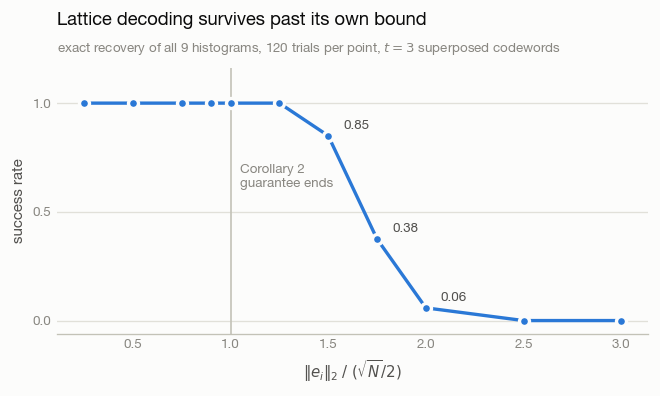

In [16]:
fig, ax = plt.subplots(figsize=(5.6, 3.4))
ax.grid(axis="y", color=T["grid"], lw=0.8)
ax.set_axisbelow(True)
ax.axvline(1.0, color=T["axis"], lw=1, zorder=1)
ax.text(1.05, 0.66, "Corollary 2\nguarantee ends", color=T["muted"], fontsize=8,
        va="center", ha="left")
ax.plot(rhos, rate, color=T["series"], lw=2, marker="o", markersize=6,
        markeredgecolor=T["surface"], markeredgewidth=2, zorder=3)
style(ax, "Lattice decoding survives past its own bound",
      f"exact recovery of all {N} histograms, {TRIALS} trials per point, "
      f"$t = {t}$ superposed codewords")
ax.set_xlabel(r"$\|e_i\|_2 \;/\; (\sqrt{N}/2)$")
ax.set_ylabel("success rate")
ax.set_ylim(-0.06, 1.16)
ax.set_yticks([0, 0.5, 1.0])
for x, y in zip(rhos, rate):        # label only the transition, never every point
    if 0.0 < y < 1.0:
        ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points", xytext=(9, 4),
                    ha="left", fontsize=8, color=T["ink2"])
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color(T["axis"])
fig.tight_layout()
plt.show()

## Step 6 — one entry point: the encoder from $(p, K, l)$

Everything above is driven by $(p, m, K)$, but $m$ is an awkward thing to have to choose.
The quantity you actually know up front is $l$, **how many items you need to superimpose and
still retrieve**. That pins $m$ down, via $\mu$.

Proposition 1 gives $\mu = 1 - D/N$, and the retrieval capacity the paper quotes from
[23, Thm. 1] is $\frac{2N-D}{2N-2D}$. Substituting $D = N(1-\mu)$ collapses that to a
function of $\mu$ alone:

$$\frac{2N-D}{2N-2D} \;=\; \frac{N(1+\mu)}{2N\mu} \;=\; \frac{1+\mu}{2\mu}.$$

So the code supports $l$ items exactly when $\frac{1+\mu}{2\mu} \ge l$, i.e. when

$$\mu \;\le\; \mu_{\max} \;=\; \frac{1}{2l-1}.$$

And since $\mu = \frac{K-1}{N} = \frac{K-1}{p^m}$ (Step 4 showed the bound is attained, so
this is the *actual* coherence, not an estimate), the design rule is a single inequality in
integers:

$$p^m \;\ge\; (K-1)(2l-1).$$

`VSACode(p, K, l)` takes the smallest $m$ satisfying that — together with $p^m \ge K$, which
Reed–Solomon needs anyway — and builds the whole encoder. Everything from Steps 0–5 is
reused; only $G$, $L$ and $H$ get rebuilt for the chosen field.

One caveat the class reports rather than hides: $l$ here is the **quasi-orthogonality**
capacity, which is a different and usually looser constraint than the number of *distinct*
codewords that §IV-B can actually recover, $\lfloor \frac{N-1}{K-1} \rfloor$ by Theorem 1
in the noiseless case. Both are printed so you can see which one binds.

In [17]:
from functools import lru_cache


class VSACode:
    """The paper's code C, built from (p, K, l).

    p : prime, the alphabet of the inner Hadamard code
    K : Reed-Solomon dimension, so the code holds p^(mK) items
    l : number of items that must stay retrievable in superposition; sets mu_max
        = 1/(2l-1) and hence the smallest usable extension degree m.

    Pass m explicitly to override the derived value.
    """

    def __init__(self, p, K, l, m=None):
        if not (isinstance(p, int) and p > 1 and
                all(p % f for f in range(2, int(p ** 0.5) + 1))):
            raise ValueError(f"p must be prime, got {p}")   # phi needs a prime field
        if K < 1:
            raise ValueError(f"K must be at least 1, got {K}")
        if l < 1:
            raise ValueError(f"l must be at least 1, got {l}")

        self.mu_max = 1.0 / (2 * l - 1)
        need = max(K, (K - 1) * (2 * l - 1))     # p^m >= K, and mu <= mu_max
        if m is None:
            m = 1
            while p ** m < need:
                m += 1
        elif p ** m < K:
            raise ValueError(f"m={m} gives N=p^m={p ** m} < K={K}")

        self.p, self.m, self.K, self.l = p, m, K, l
        self.F = GF(p, m)
        self.N = self.q = p ** m
        self.D = self.N - K + 1
        self.mu = (K - 1) / self.N
        self.length = p ** (2 * m)
        self.size = p ** (m * K)
        # [23, Thm. 1] retrieval capacity, and Thm. 1's noiseless recovery bound
        self.capacity = float("inf") if K == 1 else (1 + self.mu) / (2 * self.mu)
        self.recoverable = float("inf") if K == 1 else (self.N - 1) // (K - 1)

        betas = np.arange(self.N, dtype=np.int64)
        self.G = np.zeros((K, self.N), dtype=np.int64)     # Vandermonde, G[i,j] = beta_j^i
        self.G[0] = self.F.one
        for i in range(1, K):
            self.G[i] = self.F.MUL[self.G[i - 1], betas]

        self.L = (self.F.vec @ self.F.vec.T) % p           # Hadamard exponents
        self.H = np.exp(2j * np.pi * self.L / p)           # phi applied to L
        self.Hdag = self.H.conj().T

    # -- Step 1 ------------------------------------------------------------
    def rs_encode(self, u):
        u = np.asarray(u, dtype=np.int64)
        if u.shape != (self.K,):
            raise ValueError(f"message must have K={self.K} symbols, got {u.shape}")
        if ((u < 0) | (u >= self.q)).any():
            raise ValueError(f"symbols must lie in [0, {self.q})")
        c = np.zeros(self.N, dtype=np.int64)
        for i in range(self.K):
            c = self.F.ADD[c, self.F.MUL[int(u[i]), self.G[i]]]
        return c

    # -- Steps 2 and 3, i.e. eq. (1) ---------------------------------------
    def encode(self, u):
        """Message in F_{p^m}^K  ->  codeword in C^{p^2m}."""
        return self.H[:, self.rs_encode(u)].T.reshape(-1)

    # -- Section IV-A ------------------------------------------------------
    def histograms(self, s):
        """Superposition  ->  N histograms of F_{p^m} symbols (Corollary 1)."""
        return np.round((self.Hdag @ s.reshape(self.N, self.N).T).real / self.N).astype(int).T

    def noise_threshold(self):
        """Corollary 2's per-block sufficient radius."""
        return np.sqrt(self.N) / 2

    def __repr__(self):
        return (f"VSACode(p={self.p}, K={self.K}, l={self.l}) -> m={self.m}, N={self.N}, "
                f"length={self.length}, mu={self.mu:.4f} <= {self.mu_max:.4f}")


@lru_cache(maxsize=None)
def build_code(p, K, l, m=None):
    """Cached constructor -- building the field tables is the expensive part."""
    return VSACode(p, K, l, m)


def encode(p, K, l, u, m=None):
    """One-shot encoder: encode message u under the code determined by (p, K, l)."""
    return build_code(p, K, l, m).encode(u)

In [18]:
# --- the derived m really does deliver the requested capacity --------------
for _p, _K, _l in [(3, 2, 5), (2, 2, 3), (3, 3, 4), (5, 3, 6), (7, 2, 10), (2, 1, 50)]:
    code = build_code(_p, _K, _l)
    assert code.mu <= code.mu_max + 1e-12, f"{code} exceeds mu_max"
    assert code.capacity >= _l - 1e-9, f"{code} cannot hold l={_l}"
    assert code.N >= code.K, "RS needs N >= K"
    if code.m > 1:                       # m is minimal: one step down must fail
        assert _p ** (code.m - 1) < max(_K, (_K - 1) * (2 * _l - 1)), "m is not minimal"
    u = [int(x) for x in _rng.integers(0, code.q, code.K)]
    c = code.encode(u)
    assert c.shape == (code.length,)
    assert np.allclose(np.abs(c), 1.0)
    assert abs(np.linalg.norm(c) - np.sqrt(code.length)) < 1e-9
    v = [int(x) for x in _rng.integers(0, code.q, code.K)]
    w = [int(code.F.ADD[u[i], v[i]]) for i in range(code.K)]
    assert np.allclose(code.encode(w), code.encode(u) * code.encode(v)), "binding broke"

# --- and it agrees with the notebook's step-by-step encoder ----------------
same = build_code(p, K, 5)
if same.m == m:
    _u = [int(x) for x in _rng.integers(0, q, K)]
    assert np.allclose(same.encode(_u), encode_explicit(_u)), "VSACode disagrees with Step 3"
    print(f"VSACode(p={p}, K={K}, l=5) picks m={m} and reproduces Step 3 exactly")

print(f"{'p':>3} {'K':>3} {'l':>4} | {'m':>3} {'N':>5} {'length':>8} {'items':>8} "
      f"{'mu':>9} {'mu_max':>9} {'recoverable':>12}")
print("-" * 78)
for _p, _K, _l in [(3, 2, 2), (3, 2, 5), (3, 2, 20), (3, 3, 5), (5, 3, 6), (7, 2, 10)]:
    c_ = build_code(_p, _K, _l)
    print(f"{_p:>3} {_K:>3} {_l:>4} | {c_.m:>3} {c_.N:>5} {c_.length:>8} "
          f"{c_.size:>8} {c_.mu:>9.5f} {c_.mu_max:>9.5f} {c_.recoverable:>12}")
print("\n'items' is how many distinct objects the code can NAME (p^mK);")
print("'l' is how many can be superimposed and still retrieved (quasi-orthogonality);")
print("'recoverable' is Thm. 1's noiseless bound on distinct codewords in a superposition.")

VSACode(p=3, K=2, l=5) picks m=2 and reproduces Step 3 exactly
  p   K    l |   m     N   length    items        mu    mu_max  recoverable
------------------------------------------------------------------------------
  3   2    2 |   1     3        9        9   0.33333   0.33333            2
  3   2    5 |   2     9       81       81   0.11111   0.11111            8


  3   2   20 |   4    81     6561     6561   0.01235   0.02564           80
  3   3    5 |   3    27      729    19683   0.07407   0.11111           13
  5   3    6 |   2    25      625    15625   0.08000   0.09091           12
  7   2   10 |   2    49     2401     2401   0.02041   0.05263           48

'items' is how many distinct objects the code can NAME (p^mK);
'l' is how many can be superimposed and still retrieved (quasi-orthogonality);
'recoverable' is Thm. 1's noiseless bound on distinct codewords in a superposition.


In [19]:
# --- end to end through the (p, K, l) API, including IV-A recovery ---------
code = build_code(3, 2, 5)
print(code)

items = [[int(x) for x in _rng.integers(0, code.q, code.K)] for _ in range(code.l)]
sup = sum(code.encode(u) for u in items)                    # superpose l items

truth = np.array([np.bincount([int(code.rs_encode(u)[i]) for u in items],
                              minlength=code.q) for i in range(code.N)])
assert (code.histograms(sup) == truth).all(), "histogram recovery failed"
assert (truth.sum(axis=1) == code.l).all()
print(f"superposed l = {code.l} items, recovered all {code.N} histograms exactly")

# the same superposition, now noisy just inside Corollary 2's radius
thr = code.noise_threshold()
e = _rng.normal(size=(code.N, code.N)) + 1j * _rng.normal(size=(code.N, code.N))
e *= (0.95 * thr) / np.linalg.norm(e, axis=1, keepdims=True)
assert (code.histograms(sup + e.reshape(-1)) == truth).all(), "noisy recovery failed"
print(f"still exact with per-block noise at 0.95 * sqrt(N)/2 = {0.95 * thr:.4f}")

print(f"\nencode(p=3, K=2, l=5, u=[1, 2]) -> shape "
      f"{encode(3, 2, 5, [1, 2]).shape}, norm "
      f"{np.linalg.norm(encode(3, 2, 5, [1, 2])):.4f}")

VSACode(p=3, K=2, l=5) -> m=2, N=9, length=81, mu=0.1111 <= 0.1111
superposed l = 5 items, recovered all 9 histograms exactly
still exact with per-block noise at 0.95 * sqrt(N)/2 = 1.4250

encode(p=3, K=2, l=5, u=[1, 2]) -> shape (81,), norm 9.0000


## Summary

Everything above is asserted, so a clean run means every listed claim held for the chosen
parameters. The `p, m, K` cell at the top is the only thing to change; the notebook
re-verifies itself end to end.

Beyond the guarantee the curve degrades gracefully rather than falling off a cliff, which
matches the paper's remark after Corollary 1 that rounding "succeeds even for some
*unbounded* error vectors" — $\sqrt{N}/2$ is sufficient, not necessary.

**Not implemented:** §IV-B, histogram recovery proper — Kautz–Singleton one-hot matrices,
the Guruswami–Sudan-style list decoder of [26], inner-product filtering of spurious
codewords, and the iterative peel-off that recovers multiplicities. That is the step which
turns the histograms of Step 5 back into the Reed–Solomon codewords, completing
superposition-recovery.

In [20]:
rows = [
    ("Step 1", "RS is MDS: d = N-K+1",                 f"d = {D}"),
    ("Step 2", "f_Had linear, p^m distinct columns",   f"{N} columns"),
    ("Step 3", "phi: (F_p,+) -> ({zeta^i},.) iso",     f"zeta = exp(2i pi/{p})"),
    ("Step 3", "H H^dag = p^m I",                      f"{N} I"),
    ("eq. (1)", "H-column selection == f_Had then phi", "identical"),
    ("Prop. 1", "length p^2m, norm p^m",               f"{LENGTH}, {p ** m}"),
    ("Prop. 1", "coherence <= 1 - D/N",                f"{emp:.6f} <= {mu_bound:.6f}"),
    ("Sec. II", "binding enc(u+v) = enc(u)*enc(v)",    "holds"),
    ("Sec. II", "binding-recovery via subcodes",       "attributes read back"),
    ("Cor. 1",  "histograms from superposition",       f"t = {t}, exact"),
    ("Cor. 2",  "success for ||e_i|| < sqrt(N)/2",     f"{threshold:.4f}, 100%"),
    ("Step 6",  "(p,K,l) -> minimal m with mu<=mu_max", f"mu_max = 1/(2l-1)"),
]
w = max(len(r[1]) for r in rows)
print(f"{'paper':<9} {'claim':<{w}}  value")
print("-" * (9 + w + 2 + 24))
for ref, claim, val in rows:
    print(f"{ref:<9} {claim:<{w}}  {val}")
print(f"\np={p}, m={m}, K={K}  ->  all checks passed")

paper     claim                                 value
-----------------------------------------------------------------------
Step 1    RS is MDS: d = N-K+1                  d = 8
Step 2    f_Had linear, p^m distinct columns    9 columns
Step 3    phi: (F_p,+) -> ({zeta^i},.) iso      zeta = exp(2i pi/3)
Step 3    H H^dag = p^m I                       9 I
eq. (1)   H-column selection == f_Had then phi  identical
Prop. 1   length p^2m, norm p^m                 81, 9
Prop. 1   coherence <= 1 - D/N                  0.111111 <= 0.111111
Sec. II   binding enc(u+v) = enc(u)*enc(v)      holds
Sec. II   binding-recovery via subcodes         attributes read back
Cor. 1    histograms from superposition         t = 3, exact
Cor. 2    success for ||e_i|| < sqrt(N)/2       1.5000, 100%
Step 6    (p,K,l) -> minimal m with mu<=mu_max  mu_max = 1/(2l-1)

p=3, m=2, K=2  ->  all checks passed
